# EDA Telehealth — Subplots (estilo 1ESPA)
Notebook gerado para produzir gráficos com **subplots por família**:
- Evolução temporal (Nacional; Rural vs. Urbano)
- Distribuições (Histograma; Boxplot por RUCA)
- Demografia (Idade; Sexo; Raça/Etnia)
- Status de inscrição/eligibilidade (Dual vs. Only; Aged/Disabled/ESRD)
- Rankings estaduais (Top 10; Bottom 10)
- Correlação (heatmap)

**Padrões adotados**: matplotlib puro, 1 suptitle por família, títulos individuais em cada subplot, sem cores definidas, grade leve e `tight_layout()`.

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Config visual (sem cores definidas)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

CSV_PATH = Path("./Medicare_Telehealth_Trends_Q1_2025.csv")  # ajuste se necessário
df = pd.read_csv(CSV_PATH)

# Garantir tipos simples
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["quarter"] = pd.to_numeric(df["quarter"].astype(str).str.replace("Q","", regex=False), errors="coerce")
for c in ["Pct_Telehealth","Total_Bene_Telehealth","Total_PartB_Enrl","Total_Bene_TH_Elig"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Year","quarter","Pct_Telehealth"]).copy()
df["period"] = df["Year"].astype(int).astype(str) + "-Q" + df["quarter"].astype(int).astype(str)

# Slices úteis
NAT_ALL = (df["Bene_Geo_Desc"]=="National") & (df["Bene_RUCA_Desc"]=="All") & (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") &           (df["Bene_Mdcr_Entlmt_Stus"]=="All") & (df["Bene_Race_Desc"]=="All") & (df["Bene_Sex_Desc"]=="All") & (df["Bene_Age_Desc"]=="All")

nat = df[NAT_ALL].copy().sort_values(["Year","quarter"])
latest_year = int(nat["Year"].max())
latest_q = int(nat[nat["Year"].eq(latest_year)]["quarter"].max())

states_all = df[df["Bene_Geo_Desc"]!="National"].copy()


## Família 1 — Evolução temporal

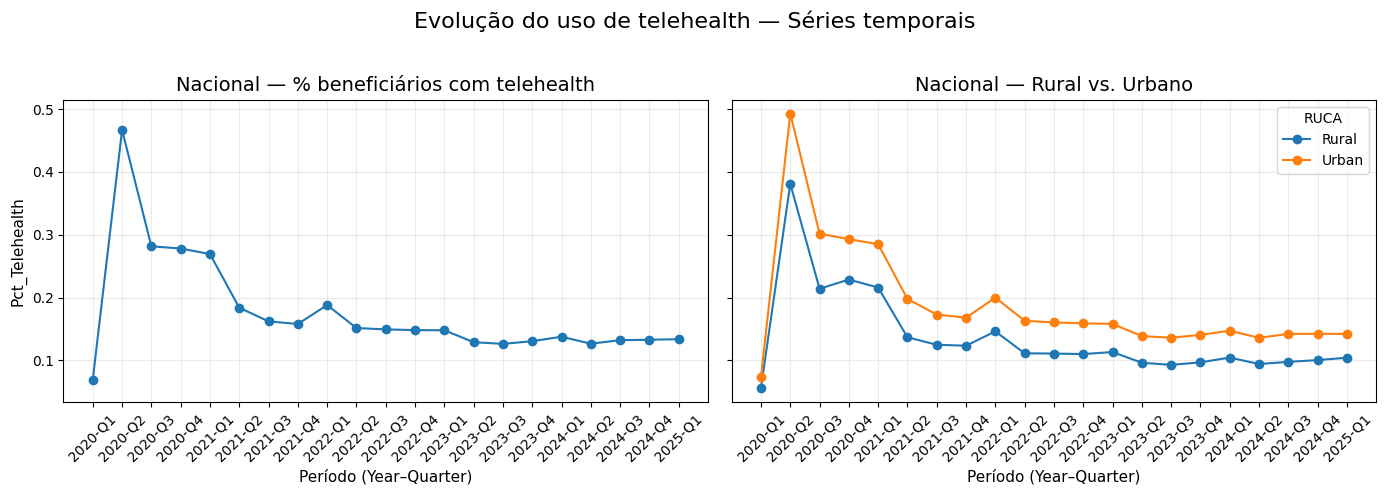

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
fig.suptitle("Evolução do uso de telehealth — Séries temporais", fontsize=16)

# 1.1 Nacional (All)
ax = axes[0]
ax.plot(nat["period"], nat["Pct_Telehealth"], marker="o")
ax.set_title("Nacional — % beneficiários com telehealth")
ax.set_xlabel("Período (Year–Quarter)")
ax.set_ylabel("Pct_Telehealth")
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

# 1.2 Rural vs. Urbano (Nacional)
ax = axes[1]
ru = df[(df["Bene_Geo_Desc"]=="National") & (df["Bene_RUCA_Desc"].isin(["Rural","Urban"])) &
        (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") & (df["Bene_Mdcr_Entlmt_Stus"]=="All") &
        (df["Bene_Race_Desc"]=="All") & (df["Bene_Sex_Desc"]=="All") & (df["Bene_Age_Desc"]=="All")].copy()
ru = ru.sort_values(["Bene_RUCA_Desc","Year","quarter"])
for grp, sub in ru.groupby("Bene_RUCA_Desc"):
    ax.plot(sub["period"], sub["Pct_Telehealth"], marker="o", label=grp)
ax.set_title("Nacional — Rural vs. Urbano")
ax.set_xlabel("Período (Year–Quarter)")
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
ax.legend(title="RUCA", loc="best")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 2 — Distribuições

C:\Users\Gustavo\AppData\Local\Temp\ipykernel_11976\4288221829.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=labels)


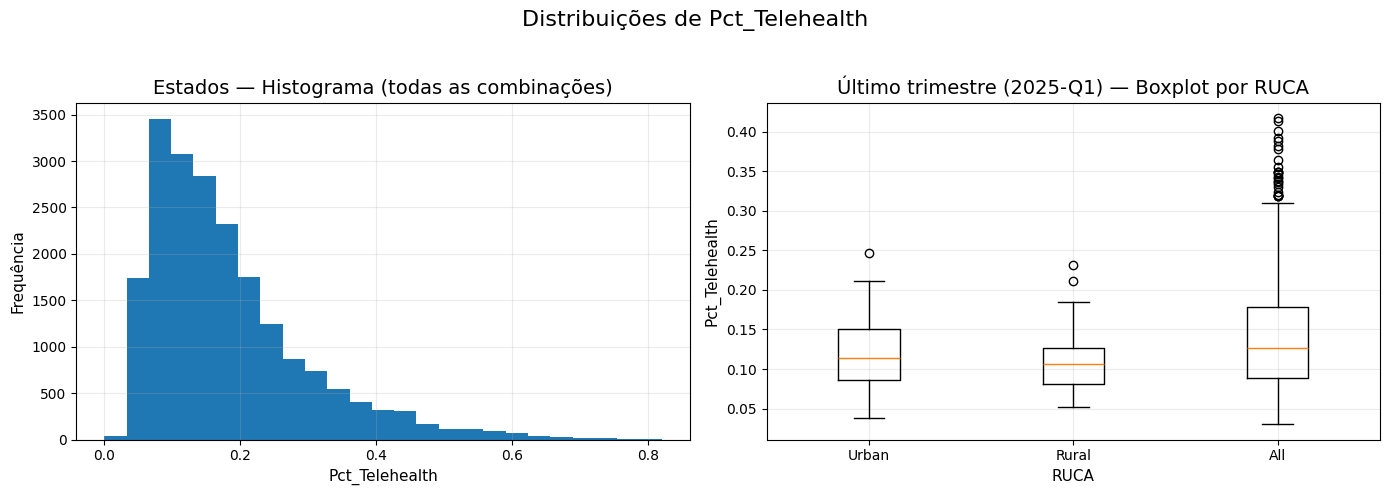

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)
fig.suptitle("Distribuições de Pct_Telehealth", fontsize=16)

# 2.1 Histograma global (estados)
ax = axes[0]
ax.hist(states_all["Pct_Telehealth"].dropna().values, bins=25)
ax.set_title("Estados — Histograma (todas as combinações)")
ax.set_xlabel("Pct_Telehealth")
ax.set_ylabel("Frequência")

# 2.2 Boxplot por RUCA (último trimestre)
ax = axes[1]
last_ru = states_all[(states_all["Year"]==latest_year) & (states_all["quarter"]==latest_q)]
ordered = ["Urban","Rural","All","Unknown"]
labels, data_box = [], []
for k in ordered:
    if (last_ru["Bene_RUCA_Desc"]==k).any():
        labels.append(k)
        data_box.append(last_ru[last_ru["Bene_RUCA_Desc"]==k]["Pct_Telehealth"].dropna().values)

ax.boxplot(data_box, labels=labels)
ax.set_title(f"Último trimestre ({latest_year}-Q{latest_q}) — Boxplot por RUCA")
ax.set_xlabel("RUCA")
ax.set_ylabel("Pct_Telehealth")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 3 — Demografia

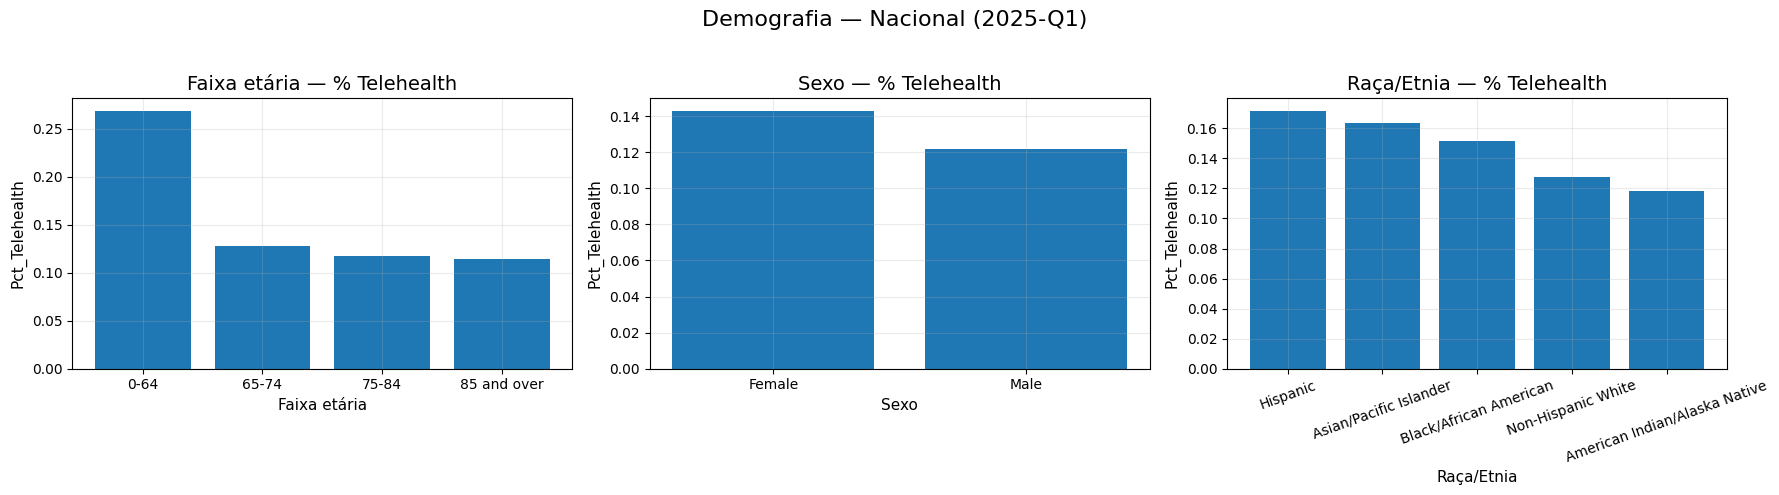

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=False)
fig.suptitle(f"Demografia — Nacional ({latest_year}-Q{latest_q})", fontsize=16)

# 3.1 Idade
ax = axes[0]
age = df[(df["Bene_Geo_Desc"]=="National") & (df["Bene_RUCA_Desc"]=="All") &
         (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") & (df["Bene_Mdcr_Entlmt_Stus"]=="All") &
         (df["Bene_Race_Desc"]=="All") & (df["Bene_Sex_Desc"]=="All") &
         (df["Year"]==latest_year) & (df["quarter"]==latest_q) &
         (df["Bene_Age_Desc"]!="All")][["Bene_Age_Desc","Pct_Telehealth"]].sort_values("Pct_Telehealth", ascending=False)
ax.bar(age["Bene_Age_Desc"], age["Pct_Telehealth"])
ax.set_title("Faixa etária — % Telehealth")
ax.set_xlabel("Faixa etária")
ax.set_ylabel("Pct_Telehealth")

# 3.2 Sexo
ax = axes[1]
sex = df[(df["Bene_Geo_Desc"]=="National") & (df["Bene_RUCA_Desc"]=="All") &
         (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") & (df["Bene_Mdcr_Entlmt_Stus"]=="All") &
         (df["Bene_Race_Desc"]=="All") & (df["Bene_Age_Desc"]=="All") &
         (df["Year"]==latest_year) & (df["quarter"]==latest_q) &
         (df["Bene_Sex_Desc"]!="All")][["Bene_Sex_Desc","Pct_Telehealth"]]
ax.bar(sex["Bene_Sex_Desc"], sex["Pct_Telehealth"])
ax.set_title("Sexo — % Telehealth")
ax.set_xlabel("Sexo")
ax.set_ylabel("Pct_Telehealth")

# 3.3 Raça/Etnia
ax = axes[2]
race = df[(df["Bene_Geo_Desc"]=="National") & (df["Bene_RUCA_Desc"]=="All") &
          (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") & (df["Bene_Mdcr_Entlmt_Stus"]=="All") &
          (df["Bene_Sex_Desc"]=="All") & (df["Bene_Age_Desc"]=="All") &
          (df["Year"]==latest_year) & (df["quarter"]==latest_q) &
          (df["Bene_Race_Desc"]!="All")][["Bene_Race_Desc","Pct_Telehealth"]].sort_values("Pct_Telehealth", ascending=False)
ax.bar(race["Bene_Race_Desc"], race["Pct_Telehealth"])
ax.set_title("Raça/Etnia — % Telehealth")
ax.set_xlabel("Raça/Etnia")
ax.set_ylabel("Pct_Telehealth")
for tick in ax.get_xticklabels():
    tick.set_rotation(20)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 4 — Status de inscrição/eligibilidade

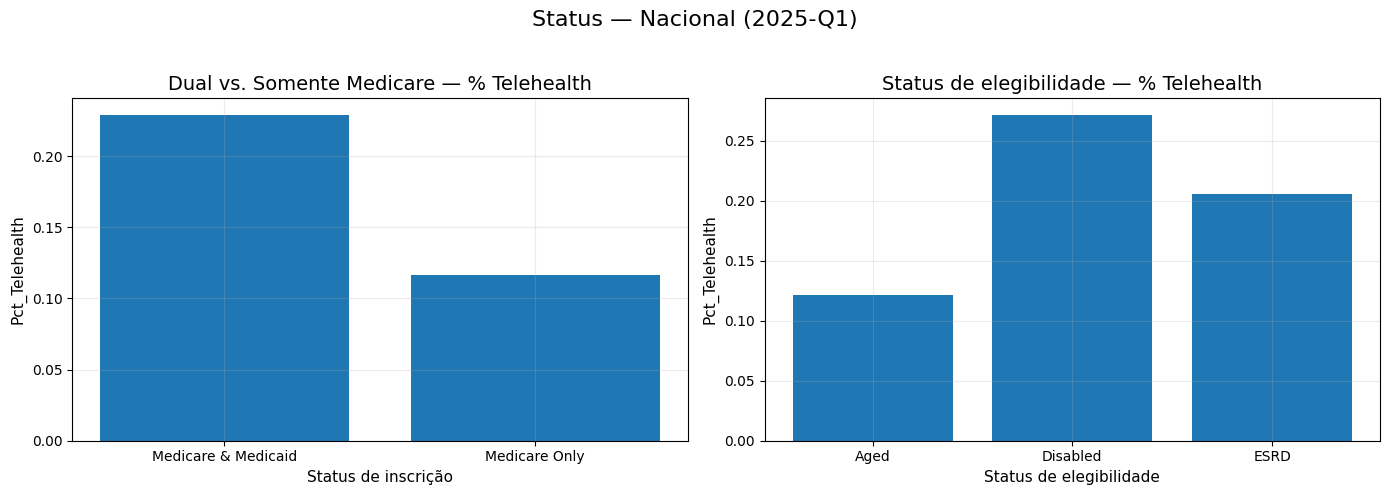

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)
fig.suptitle(f"Status — Nacional ({latest_year}-Q{latest_q})", fontsize=16)

# 4.1 Dual vs Only
ax = axes[0]
dual = df[(df["Bene_Geo_Desc"]=="National") & (df["Bene_RUCA_Desc"]=="All") &
          (df["Bene_Mdcd_Mdcr_Enrl_Stus"].isin(["Medicare & Medicaid","Medicare Only"])) &
          (df["Bene_Mdcr_Entlmt_Stus"]=="All") & (df["Bene_Race_Desc"]=="All") &
          (df["Bene_Sex_Desc"]=="All") & (df["Bene_Age_Desc"]=="All") &
          (df["Year"]==latest_year) & (df["quarter"]==latest_q)][["Bene_Mdcd_Mdcr_Enrl_Stus","Pct_Telehealth"]]
ax.bar(dual["Bene_Mdcd_Mdcr_Enrl_Stus"], dual["Pct_Telehealth"])
ax.set_title("Dual vs. Somente Medicare — % Telehealth")
ax.set_xlabel("Status de inscrição")
ax.set_ylabel("Pct_Telehealth")

# 4.2 Elegibilidade (Aged/Disabled/ESRD)
ax = axes[1]
ent = df[(df["Bene_Geo_Desc"]=="National") & (df["Bene_RUCA_Desc"]=="All") &
         (df["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") & (df["Bene_Mdcr_Entlmt_Stus"]!="All") &
         (df["Bene_Race_Desc"]=="All") & (df["Bene_Sex_Desc"]=="All") &
         (df["Bene_Age_Desc"]=="All") & (df["Year"]==latest_year) & (df["quarter"]==latest_q)][["Bene_Mdcr_Entlmt_Stus","Pct_Telehealth"]]
ax.bar(ent["Bene_Mdcr_Entlmt_Stus"], ent["Pct_Telehealth"])
ax.set_title("Status de elegibilidade — % Telehealth")
ax.set_xlabel("Status de elegibilidade")
ax.set_ylabel("Pct_Telehealth")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 5 — Rankings estaduais

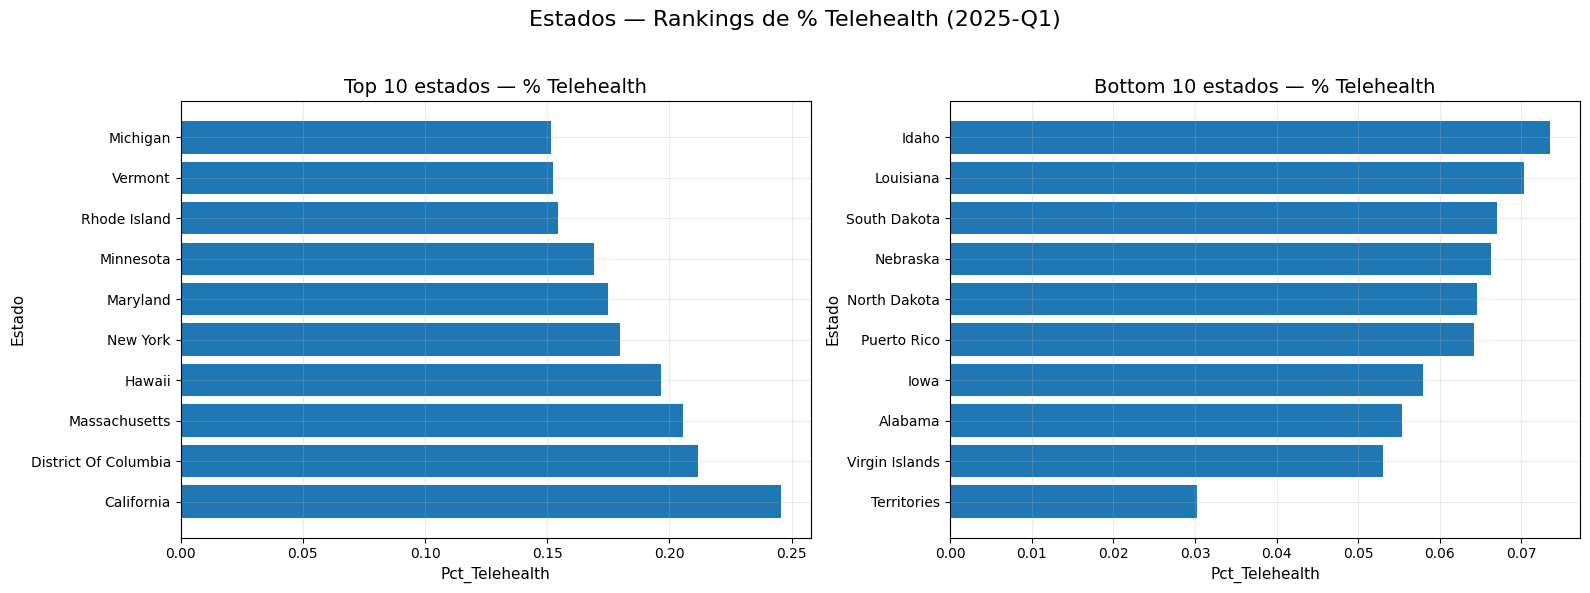

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=False)
fig.suptitle(f"Estados — Rankings de % Telehealth ({latest_year}-Q{latest_q})", fontsize=16)

state_latest = states_all[(states_all["Year"]==latest_year) & (states_all["quarter"]==latest_q) &
                          (states_all["Bene_RUCA_Desc"]=="All") & (states_all["Bene_Mdcd_Mdcr_Enrl_Stus"]=="All") &
                          (states_all["Bene_Mdcr_Entlmt_Stus"]=="All") & (states_all["Bene_Race_Desc"]=="All") &
                          (states_all["Bene_Sex_Desc"]=="All") & (states_all["Bene_Age_Desc"]=="All")][["Bene_Geo_Desc","Pct_Telehealth"]]

top10 = state_latest.nlargest(10, "Pct_Telehealth")
bot10 = state_latest.nsmallest(10, "Pct_Telehealth")

# 5.1 Top 10
ax = axes[0]
ax.barh(top10["Bene_Geo_Desc"], top10["Pct_Telehealth"])
ax.set_title("Top 10 estados — % Telehealth")
ax.set_xlabel("Pct_Telehealth")
ax.set_ylabel("Estado")

# 5.2 Bottom 10
ax = axes[1]
ax.barh(bot10["Bene_Geo_Desc"], bot10["Pct_Telehealth"])
ax.set_title("Bottom 10 estados — % Telehealth")
ax.set_xlabel("Pct_Telehealth")
ax.set_ylabel("Estado")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Família 6 — Correlação (numéricas)

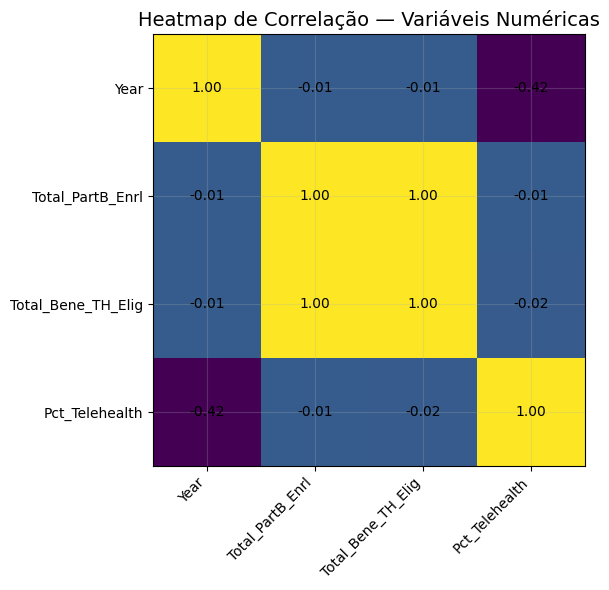

In [10]:

num_df = df[["Year","Total_PartB_Enrl","Total_Bene_TH_Elig","Pct_Telehealth"]].dropna()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr.values, interpolation="nearest")
plt.title("Heatmap de Correlação — Variáveis Numéricas")
plt.xticks(range(corr.shape[1]), corr.columns, rotation=45, ha="right")
plt.yticks(range(corr.shape[0]), corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()
